In [1]:
import pymc as pm; import arviz as az; import sys; import numpy as np; import pickle; import pytensor
import nutpie; import pytensor.tensor as pt; import matplotlib.pyplot as plt
sys.path.append(r'C:\Users\awast\OneDrive\Desktop\MKM')
from _CO_Oxidation.config import kb_eV, T, kb_J, h, F, N_A
from _CO_Oxidation import wrapper_base as wp
from _CO_Oxidation.wrapper_base import plot_posteriors, plot_model_fits, plot_coverages, plot_drc, simulate_fake_data

C_KOH_list = np.array([0.25, 0.5, 1]) # in M 
P_CO_list = 0.01*np.array([0.1, 1, 10, 100]) # in atm 
experiments_data = pickle.load(open('import_Ag50Pd50_base_replicates.pkl', 'rb'))
wp.process_experimental_data(experiments_data, C_KOH_list, P_CO_list)
E_in = wp.E_in; P_CO_in = wp.P_CO_in; C_KOH_in = wp.C_KOH_in

def fit_and_evaluate(model, draws=1000, tune=2000, chains=4, cores=4, init_mean=None, target_accept=0.9):
    compiled_model = nutpie.compile_pymc_model(model)
    trace = nutpie.sample(compiled_model, draws=draws, tune=tune, chains=chains, cores=cores, init_mean=init_mean, target_accept=target_accept)
    pm.compute_log_likelihood(trace, progressbar=False, model=model)
    loo = az.loo(trace, pointwise=True)
    print(loo); az.plot_khat(loo); plt.title("Pareto k diagnostic"); plt.show()
    trace = wp.add_post_sampling_observables(trace)
    return trace, loo

def observables(log_rate):
    pm.Deterministic('log_rate', log_rate)
    sigma_rel = pm.HalfNormal('sigma_rel', sigma=0.1) # 0.1
    sigma_exp = wp.log_rate_SD_obs 
    sigma_tot = pm.math.sqrt(sigma_rel**2 + sigma_exp**2)
    rate = pm.LogNormal('rate', mu=log_rate, sigma=sigma_tot, observed=wp.rate_obs_matrix)
    return rate

Ag_comp = 0.5

# BF (!)
Good model. 

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.20,63
,3000,0,0.19,15
,3000,0,0.20,63
,3000,0,0.20,31


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   622.00    55.45
p_loo        5.96        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



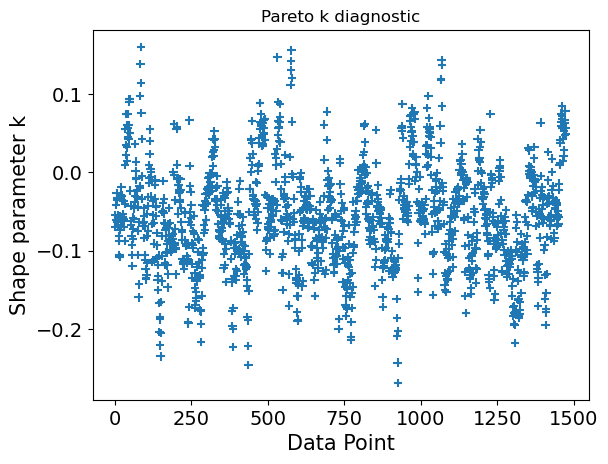

Sampling: [Gact2_0, beta_2, deltaG1_0, deltaG4_0, deltaG5_0, q, sigma_rel]


            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0 -0.120  0.001  -0.122   -0.119        0.0      0.0    2537.0    2312.0    1.0
deltaG4_0  0.085  0.002   0.081    0.089        0.0      0.0    1543.0    2331.0    1.0
deltaG5_0  0.007  0.002   0.003    0.012        0.0      0.0     826.0    1129.0    1.0
beta_2     0.007  0.006   0.000    0.018        0.0      0.0    1442.0    1304.0    1.0
q          0.279  0.007   0.266    0.291        0.0      0.0    1239.0    1779.0    1.0
Gact2_0    0.677  0.002   0.675    0.680        0.0      0.0     846.0    1105.0    1.0
sigma_rel  0.287  0.007   0.274    0.301        0.0      0.0    4573.0    2660.0    1.0

--- Prior-to-Posterior Contraction ---
deltaG1_0: 1.000
deltaG4_0: 1.000
deltaG5_0: 1.000
beta_2: 1.000
q: 0.999
Gact2_0: 1.000
sigma_rel: 0.986


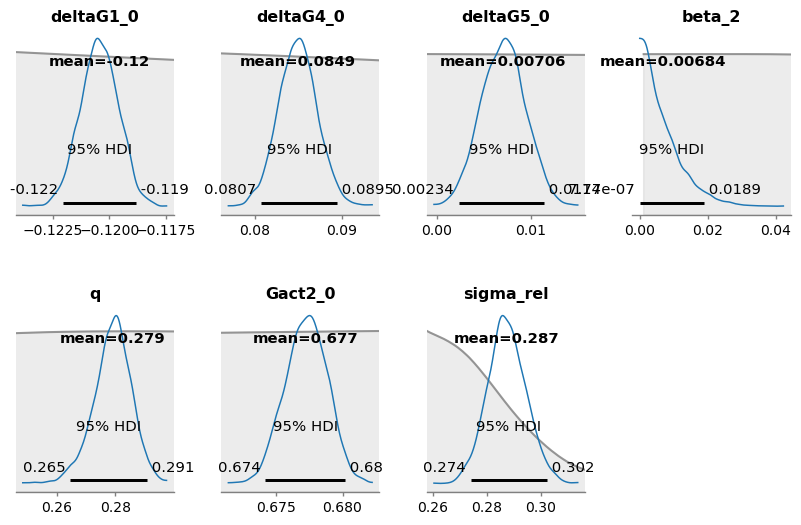

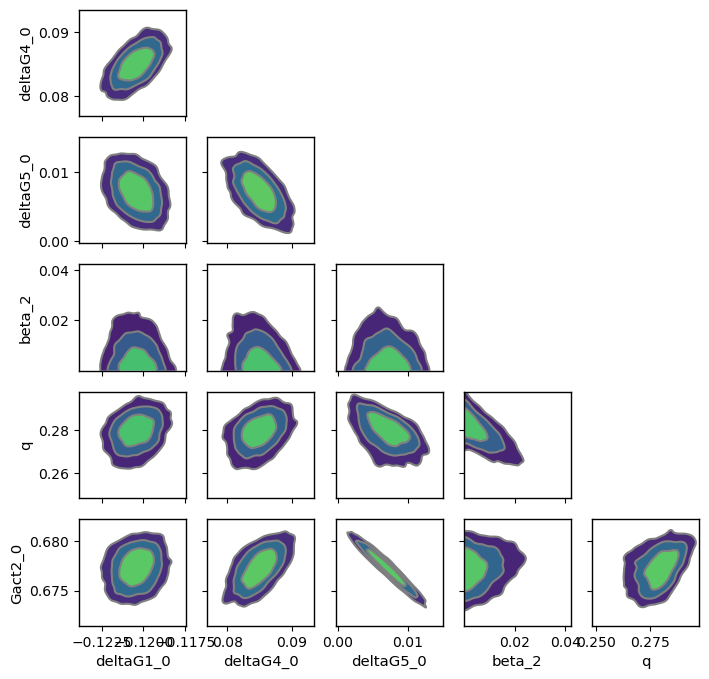

Sampling: [rate]


rate: 0.756


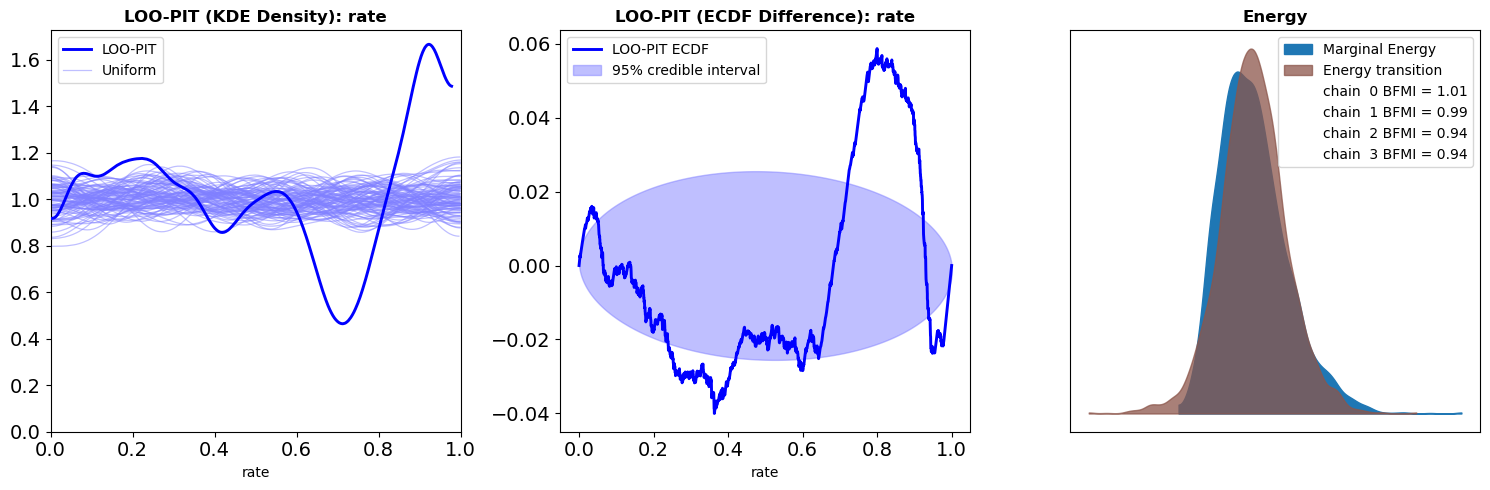

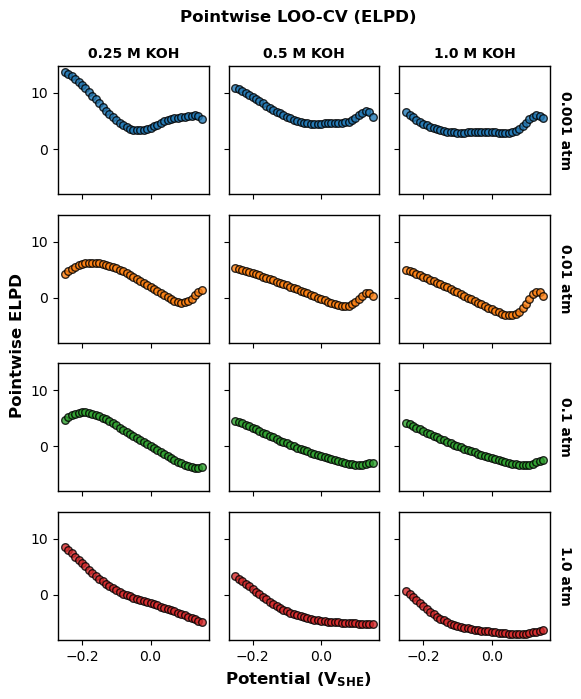

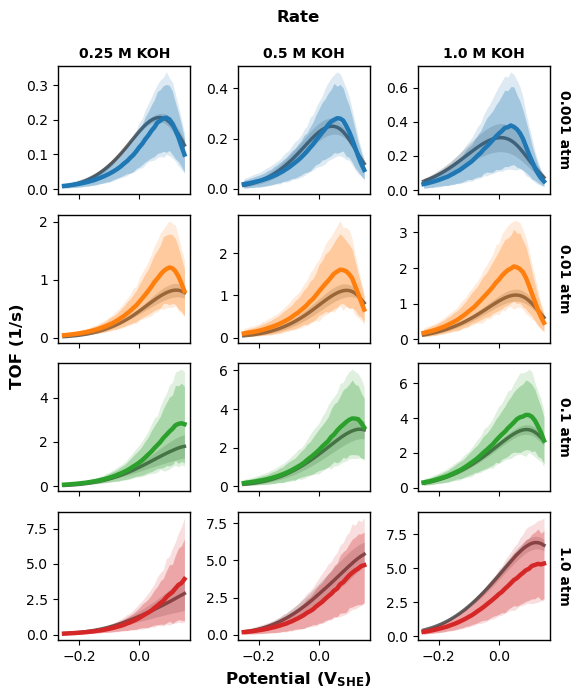

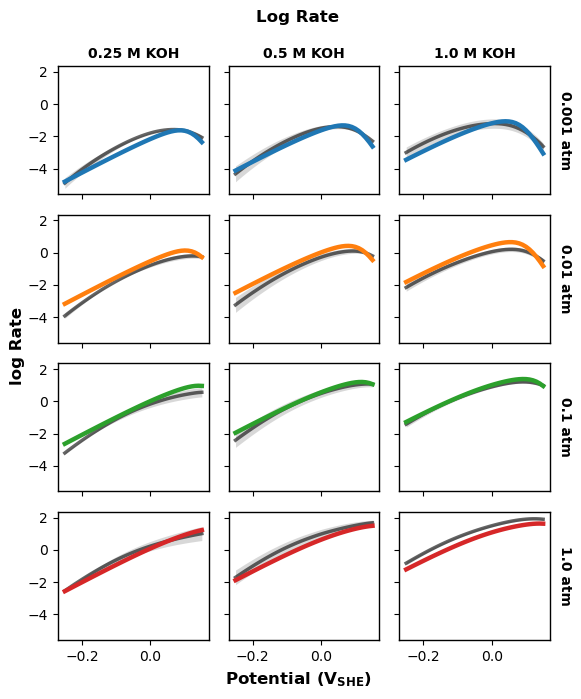

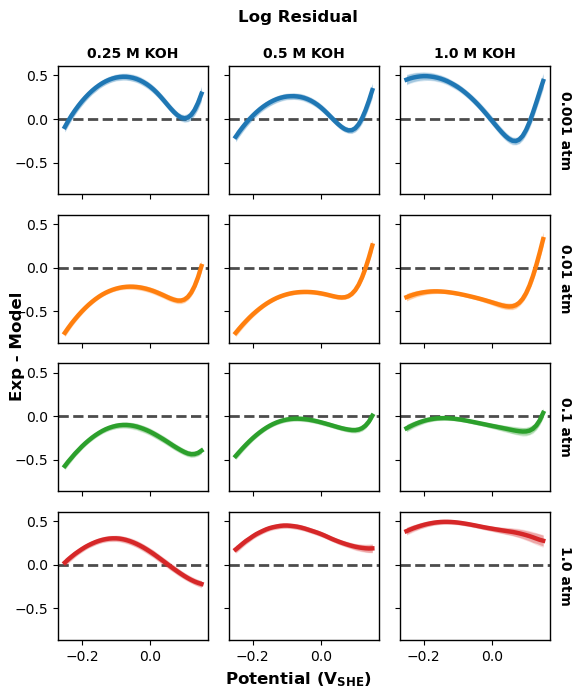

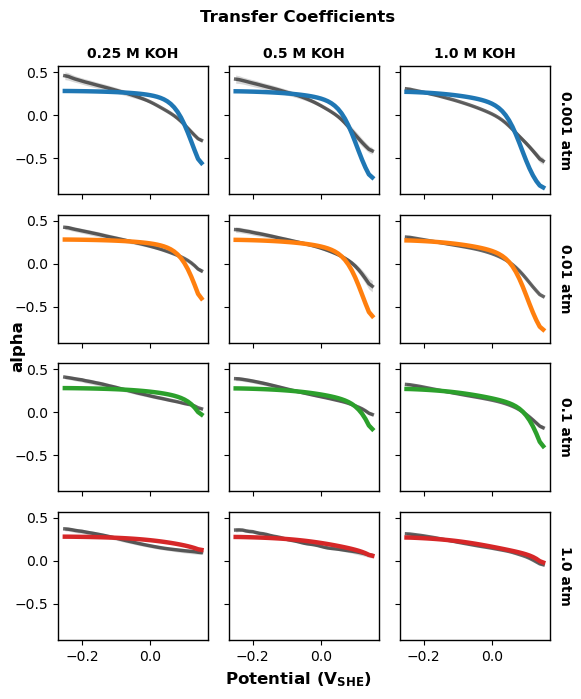

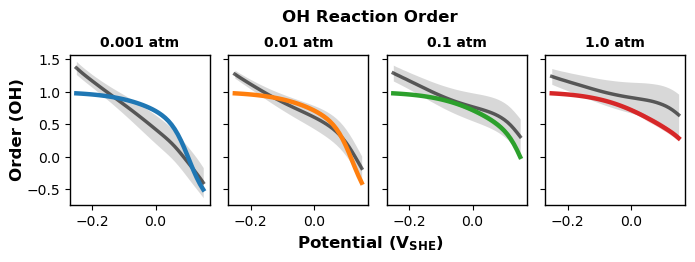

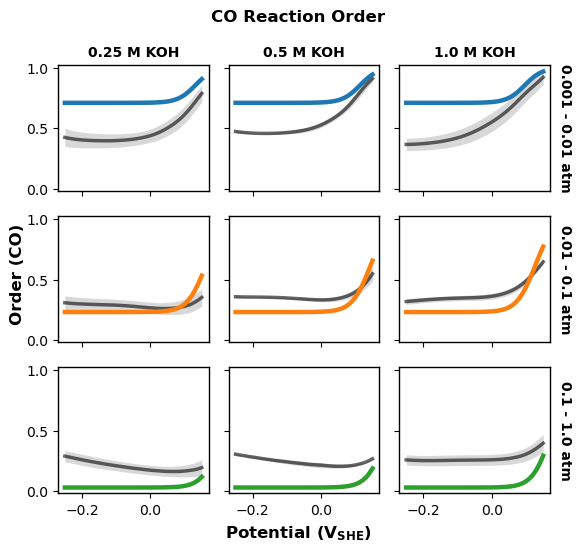

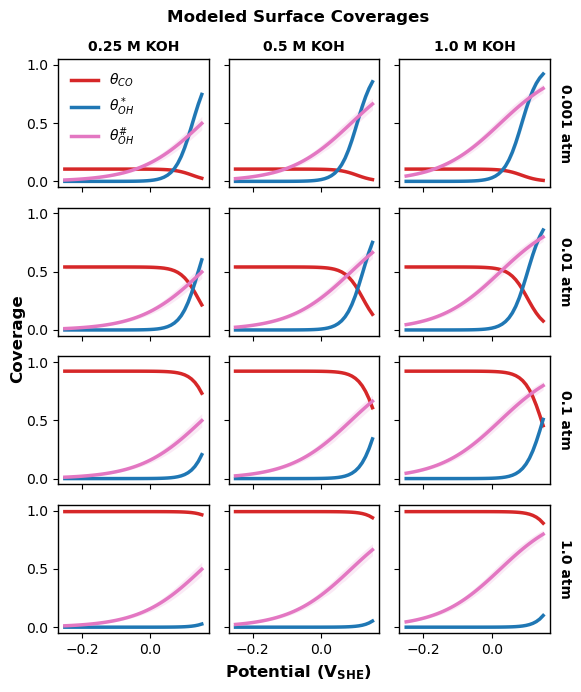

In [2]:
with pm.Model() as BF:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (RDS) (BF)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2)
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) 
    beta_2 = pm.Uniform('beta_2', lower=0.0, upper=1.0)
    q = pm.Uniform('q', lower=0.0, upper=1.0)   
    Gact2_0 = pm.TruncatedNormal('Gact2_0', mu=0.7, sigma=0.2, lower=0.0)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact2 = Gact2_0 - beta_2 * (1.0 - q) * E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2 + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate = log_rate_BF
    rate = observables(log_rate) 

trace_BF, loo_BF = fit_and_evaluate(BF, target_accept=0.95)

ppc_BF = plot_posteriors(trace_BF, BF)
plot_model_fits(trace_BF, ppc_BF, loo_BF); plot_coverages(trace_BF)

# BF ER (!)
Higher ELPD but hard to say if its statistically significant (deltaELPD/dse = 3.33) 

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.17,31
,3000,0,0.17,31
,3000,0,0.17,63
,3000,0,0.18,15


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   634.02    55.91
p_loo       19.27        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



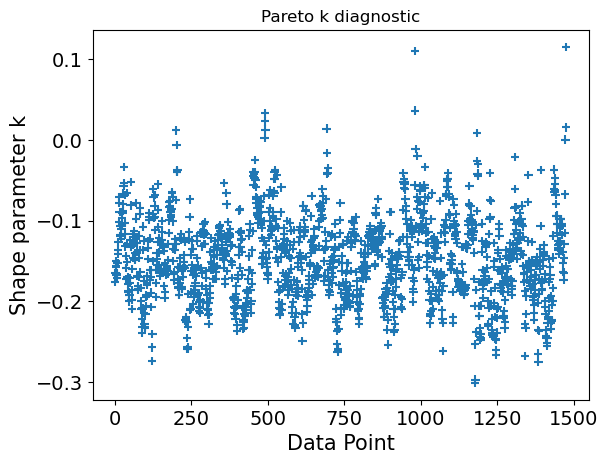

Sampling: [Gact2_BF_0, Gact2_ER_0, beta_2_BF, beta_2_ER, deltaG1_0, deltaG4_0, deltaG5_0, q, sigma_rel]


             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.121  0.001  -0.122   -0.119      0.000    0.000      17.0     192.0   1.15
deltaG4_0   0.082  0.005   0.075    0.090      0.002    0.000       6.0     125.0   1.69
deltaG5_0  -0.020  0.021  -0.050    0.006      0.010    0.000       6.0     184.0   1.74
beta_2_BF   0.007  0.009   0.000    0.022      0.002    0.001      19.0     186.0   1.14
beta_2_ER   0.571  0.363   0.198    0.992      0.180    0.001       6.0     153.0   1.73
q           0.367  0.081   0.276    0.489      0.039    0.001       6.0     204.0   1.74
Gact2_BF_0  0.699  0.017   0.679    0.721      0.009    0.000       6.0     212.0   1.74
Gact2_ER_0  0.793  0.062   0.727    0.865      0.031    0.000       6.0     210.0   1.74
sigma_rel   0.283  0.007   0.270    0.296      0.000    0.000    4990.0    2876.0   1.01

--- Prior-to-Posterior Contraction ---
deltaG1_0: 1.000
deltaG4_0: 0.999
deltaG5_0: 0.989
beta_2_BF: 0.999
be

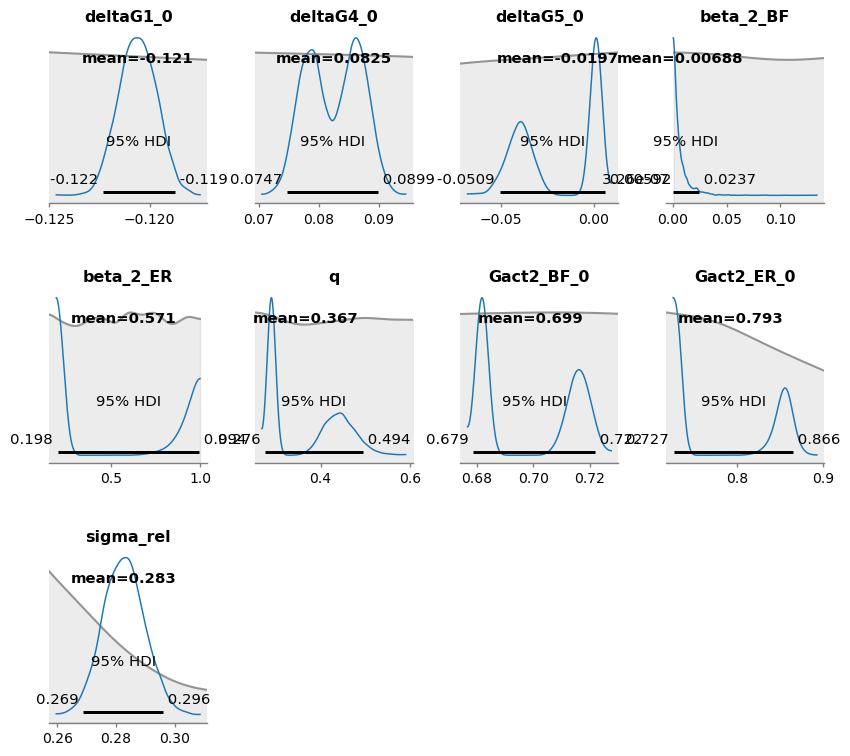

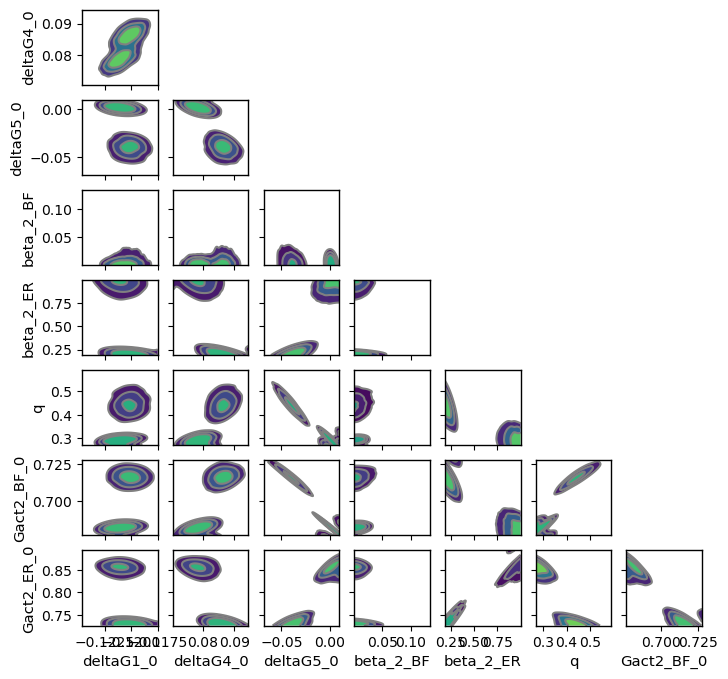

Sampling: [rate]


rate: 0.766


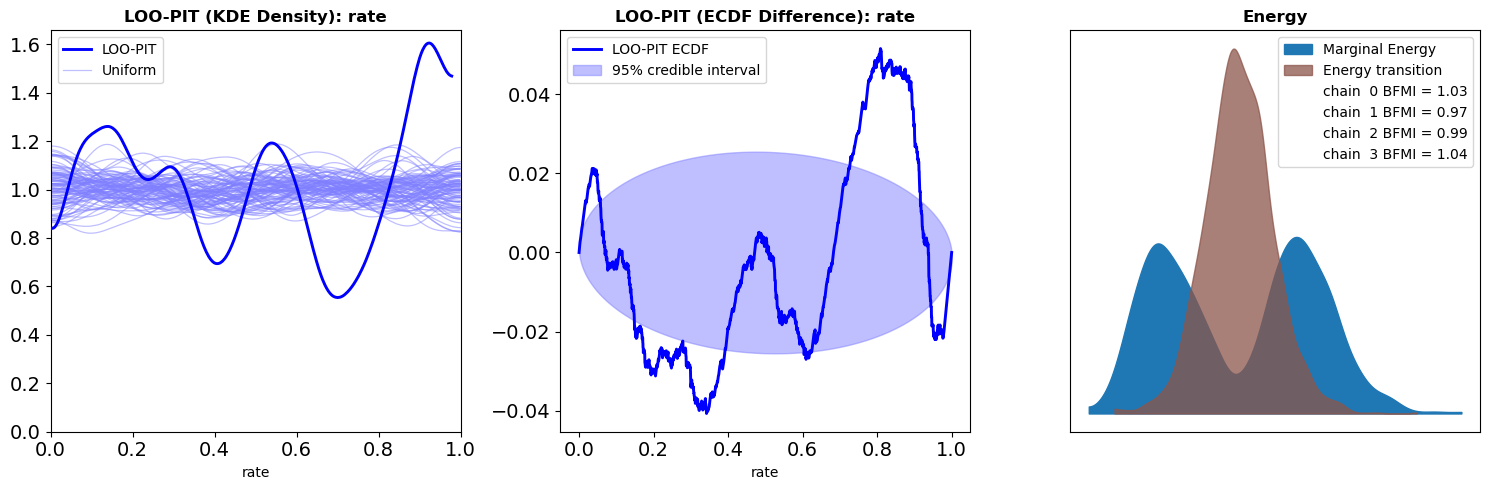

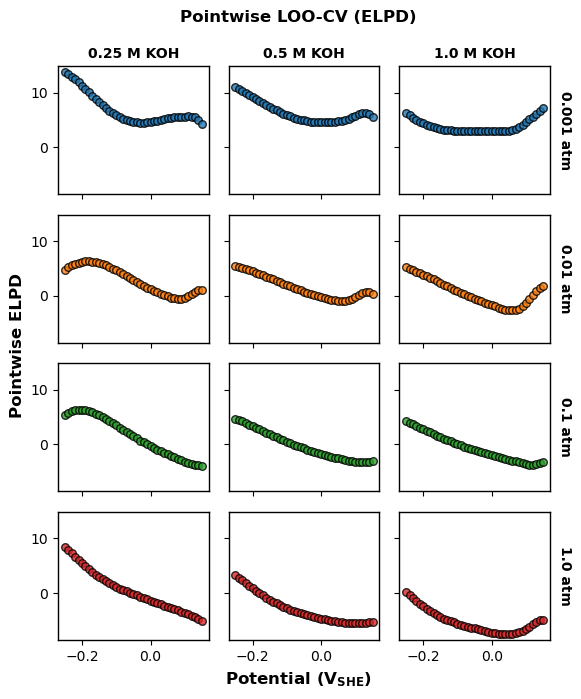

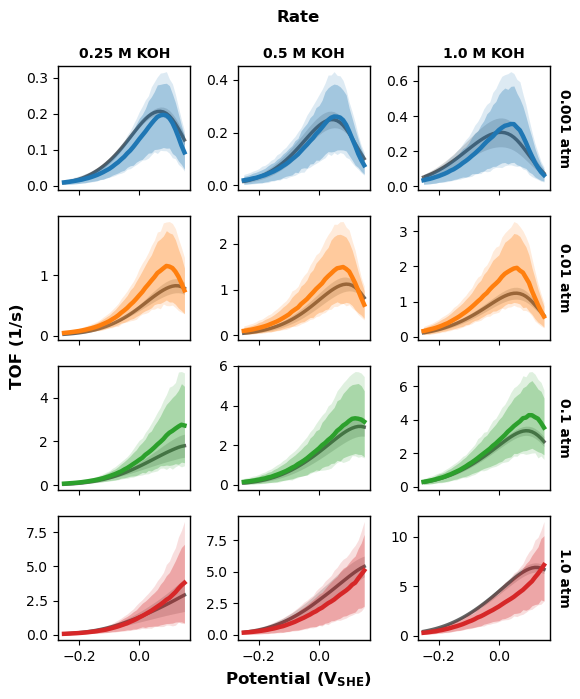

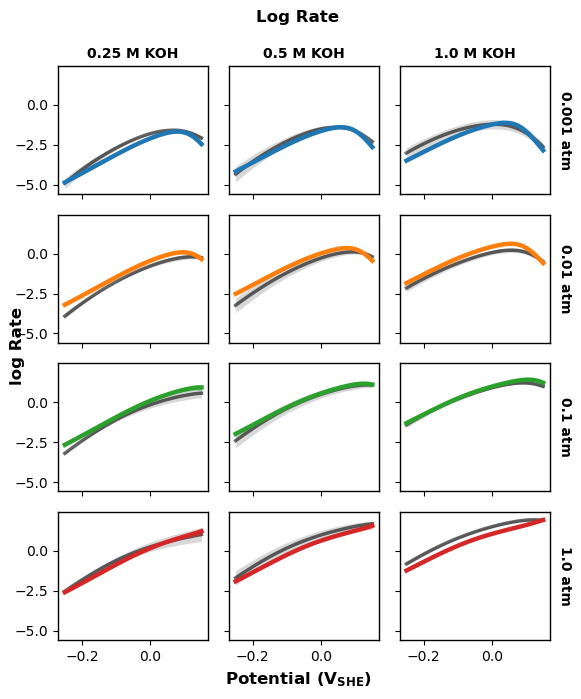

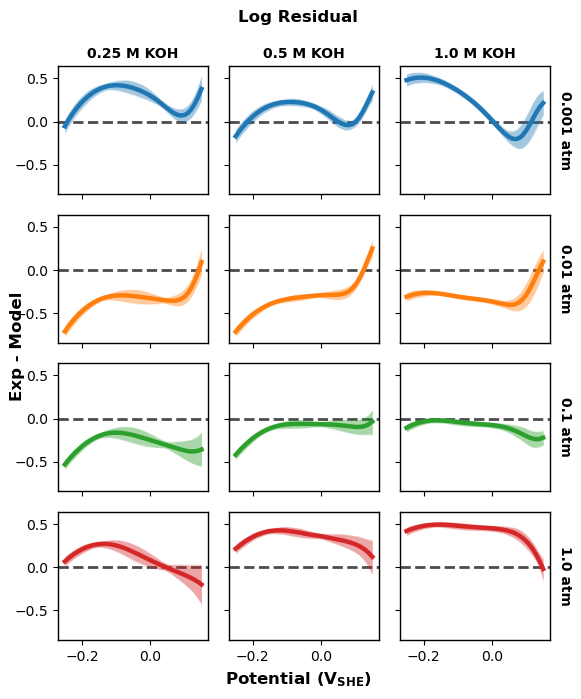

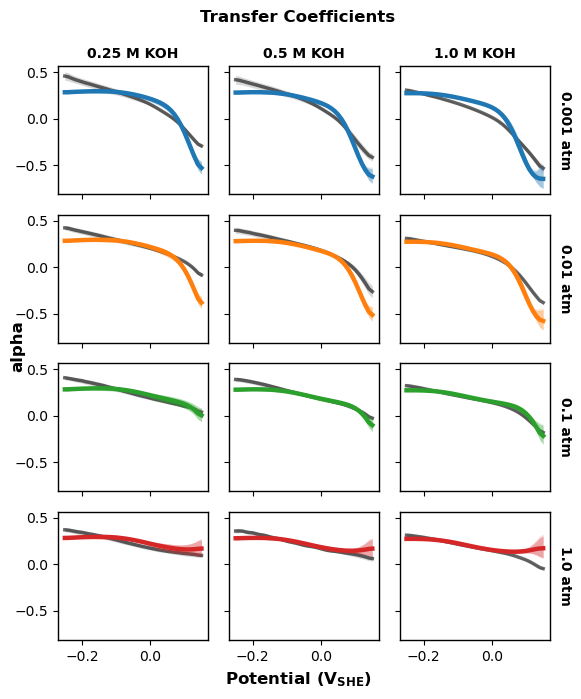

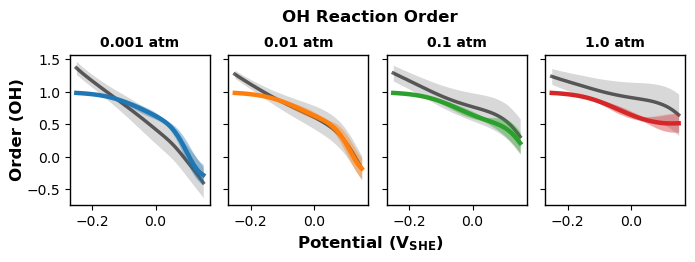

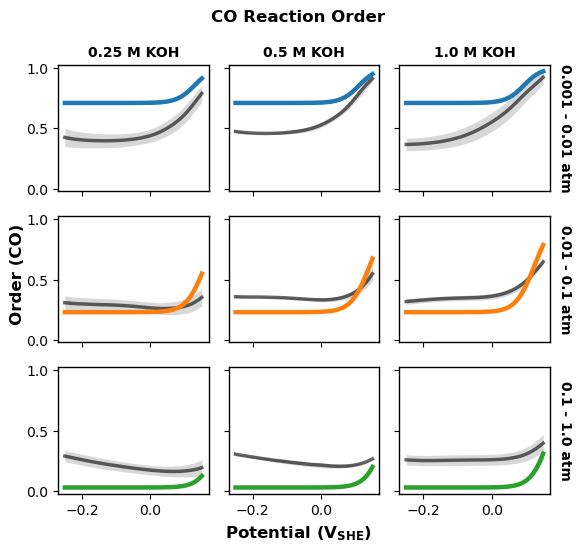

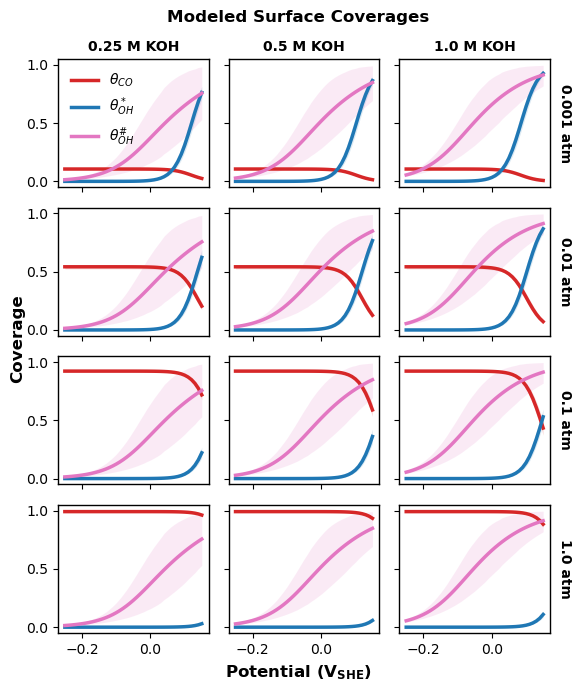

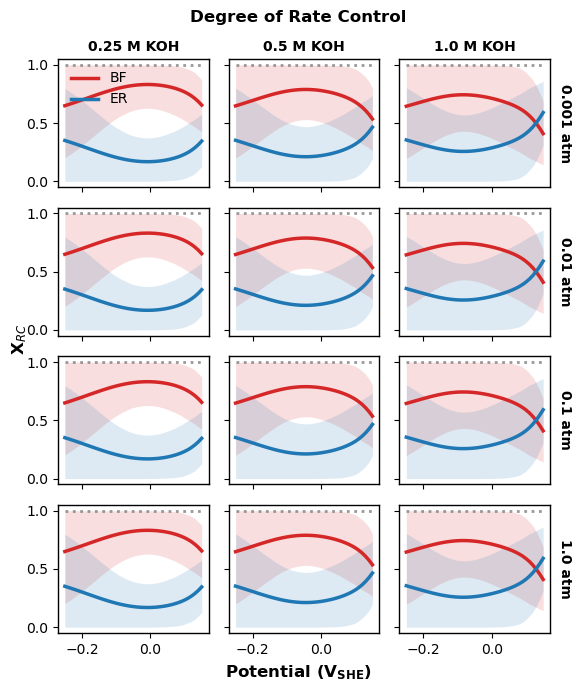

In [3]:
with pm.Model() as BF_ER:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (RDS) (BF)
    2b. CO* + OH- -> COOH* + (e-) (RDS) (ER)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2)
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2)
    beta_2_BF = pm.Uniform('beta_2_BF', lower=0.0, upper=1.0)
    beta_2_ER = pm.Uniform('beta_2_ER', lower=0.0, upper=1.0) # upper=0.4 
    q = pm.Uniform('q', lower=0.0, upper=1.0)
    Gact2_BF_0 = pm.TruncatedNormal('Gact2_BF_0', mu=0.7, sigma=0.2, lower=0.0)
    Gact2_ER_0 = pm.TruncatedNormal('Gact2_ER_0', mu=0.7, sigma=0.2, lower=0.0)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact2_BF = Gact2_BF_0 - beta_2_BF * (1.0 - q) * E_in
    Gact2_ER = Gact2_ER_0 - beta_2_ER * E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta_Pd = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH_Pd]), axis=0)
    log_theta_Ag = - pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_CO = term_CO + log_theta_Pd
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_rate_BF = log_k2_BF + log_theta_CO + log_theta_OH_Ag + np.log(Ag_comp)
    log_rate_ER = log_k2_ER + log_theta_CO + np.log(C_KOH_in)
    log_rate = pt.logaddexp(log_rate_BF, log_rate_ER)
    rate = observables(log_rate) 

trace_BF_ER, loo_BF_ER = fit_and_evaluate(BF_ER, target_accept=0.95)

ppc_BF_ER = plot_posteriors(trace_BF_ER, BF_ER)
plot_model_fits(trace_BF_ER, ppc_BF_ER, loo_BF_ER); plot_coverages(trace_BF_ER)
plot_drc(BF_ER, trace_BF_ER, perturb_vars=['Gact2_BF_0', 'Gact2_ER_0'], perturb_labels=['BF', 'ER'])

# CO BF ER (!!)
Better than BF, but hard to say when compared with BF_ER (deltaELPD/dse = 3.93)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.23,31
,3000,0,0.21,31
,3000,0,0.25,15
,3000,0,0.23,15


Computed from 4000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   678.94    55.82
p_loo        7.79        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



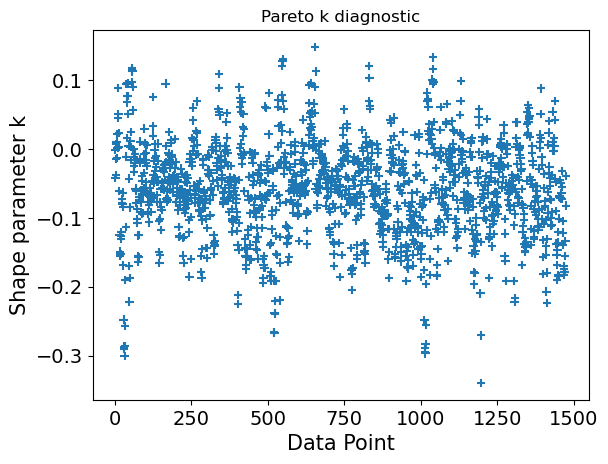

Sampling: [Gact1_0, Gact2_BF_0, Gact2_ER_0, beta_2_BF, beta_2_ER, deltaG1_0, deltaG4_0, deltaG5_0, q, sigma_rel]


             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0  -0.127  0.001  -0.130   -0.125      0.000    0.000    2709.0    2848.0    1.0
deltaG4_0   0.103  0.003   0.098    0.108      0.000    0.000    2403.0    2780.0    1.0
deltaG5_0  -0.051  0.009  -0.068   -0.034      0.000    0.000     801.0    1094.0    1.0
beta_2_BF   0.010  0.011   0.000    0.030      0.000    0.000    2248.0    1983.0    1.0
beta_2_ER   0.217  0.005   0.208    0.227      0.000    0.000    2937.0    2405.0    1.0
q           0.540  0.052   0.445    0.639      0.002    0.001     810.0    1287.0    1.0
Gact1_0     0.582  0.003   0.576    0.588      0.000    0.000    2065.0    2132.0    1.0
Gact2_BF_0  0.724  0.004   0.716    0.732      0.000    0.000     806.0    1468.0    1.0
Gact2_ER_0  0.725  0.002   0.722    0.728      0.000    0.000     887.0    1689.0    1.0
sigma_rel   0.272  0.007   0.260    0.286      0.000    0.000    5373.0    2811.0    1.0

--- Prior-to-Posteri

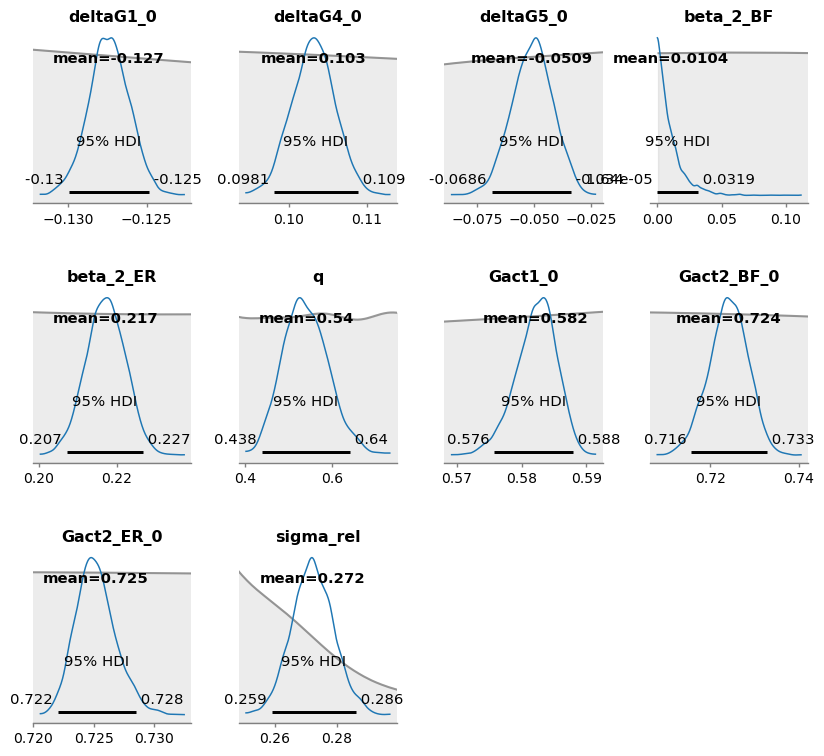

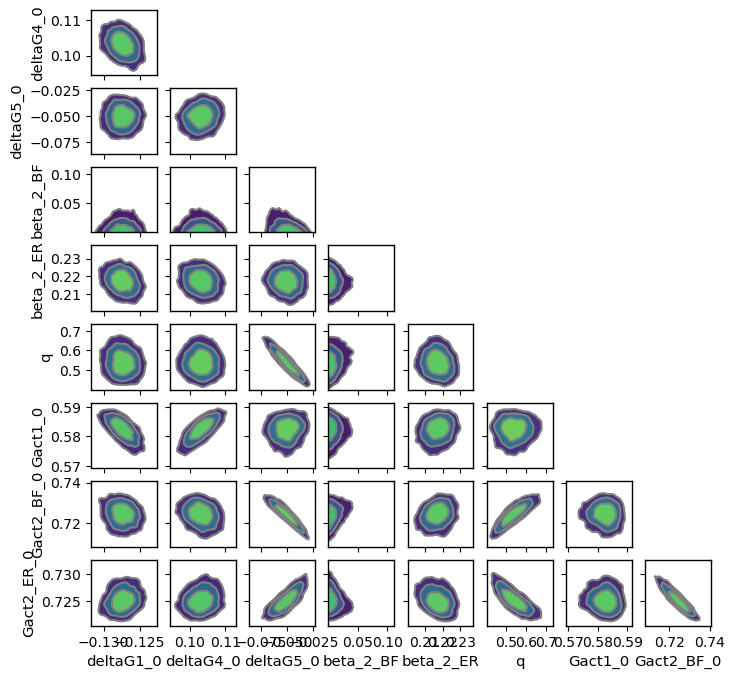

Sampling: [rate]


rate: 0.796


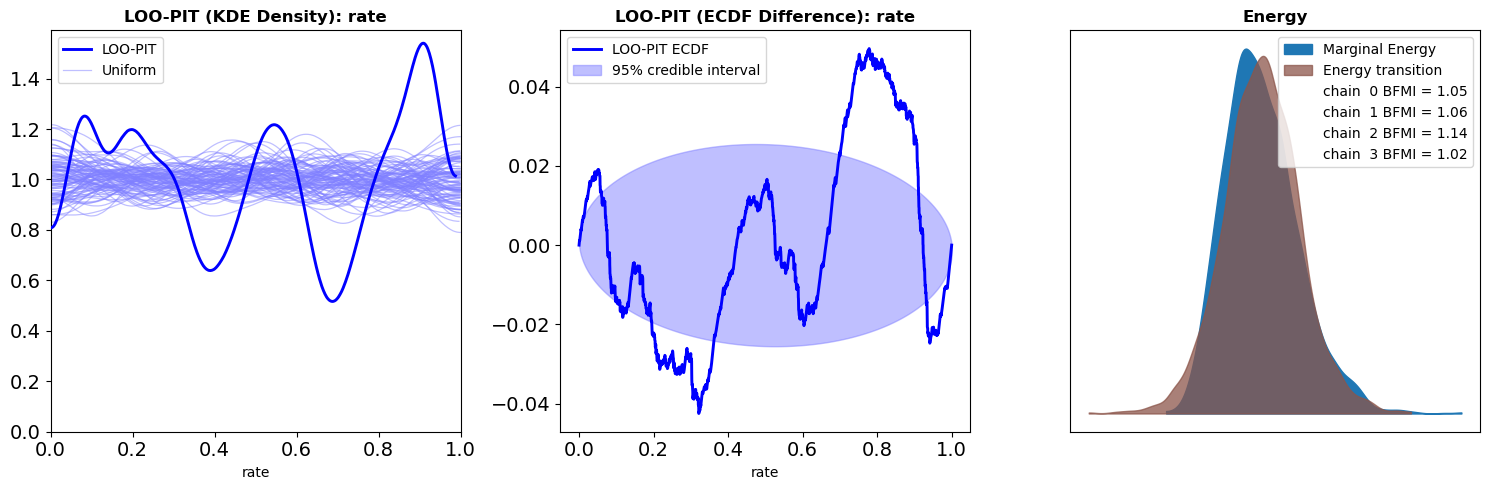

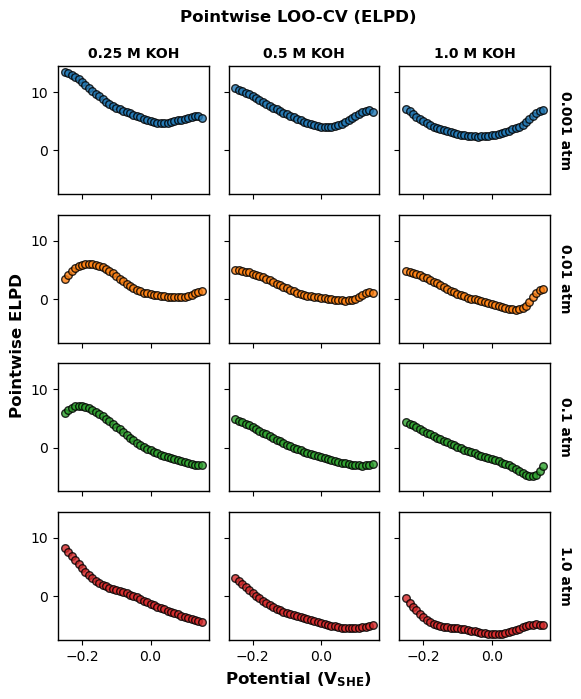

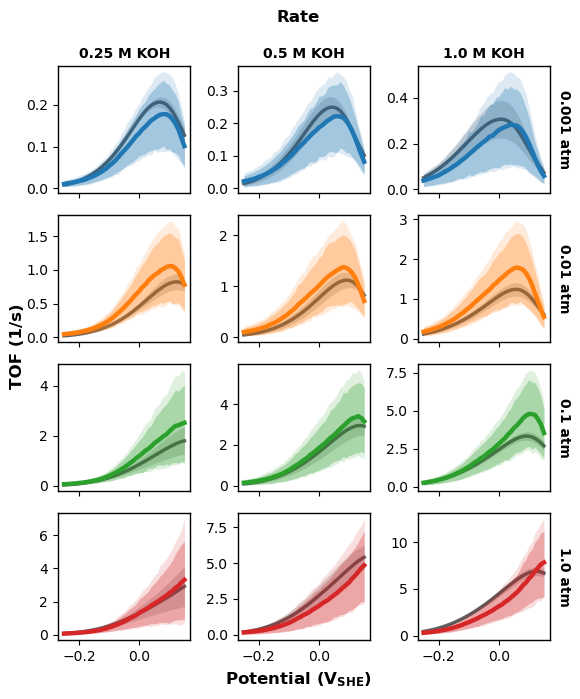

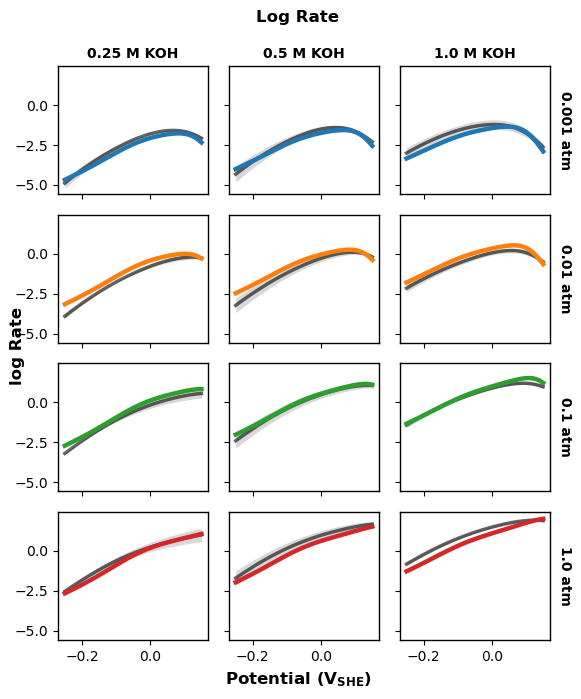

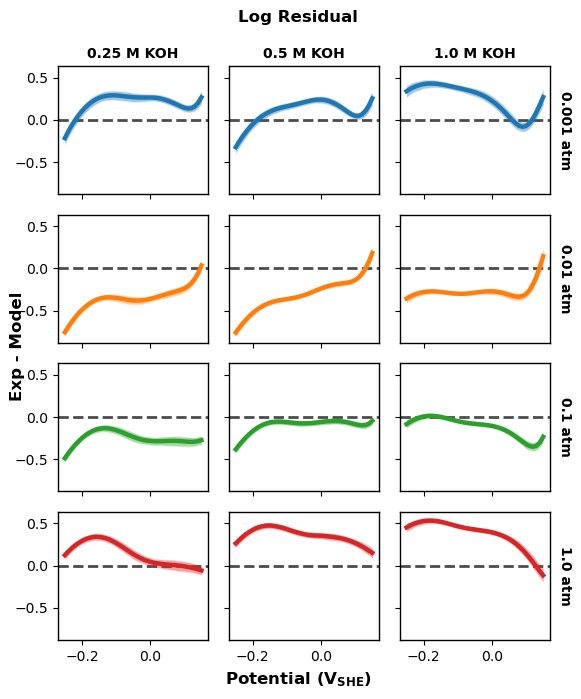

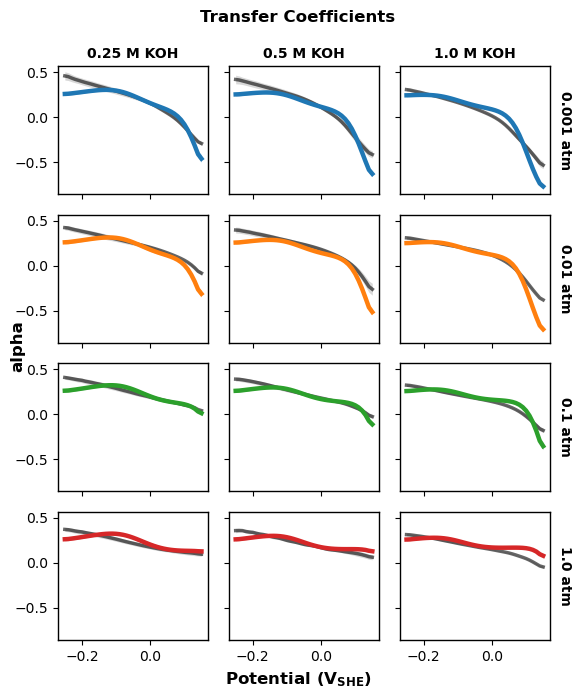

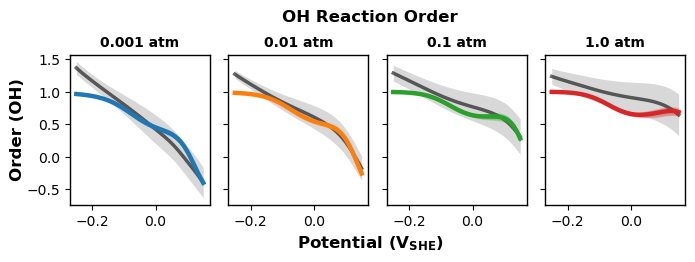

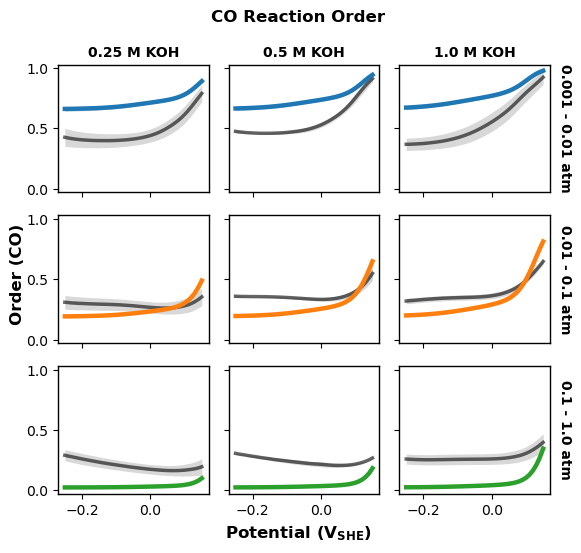

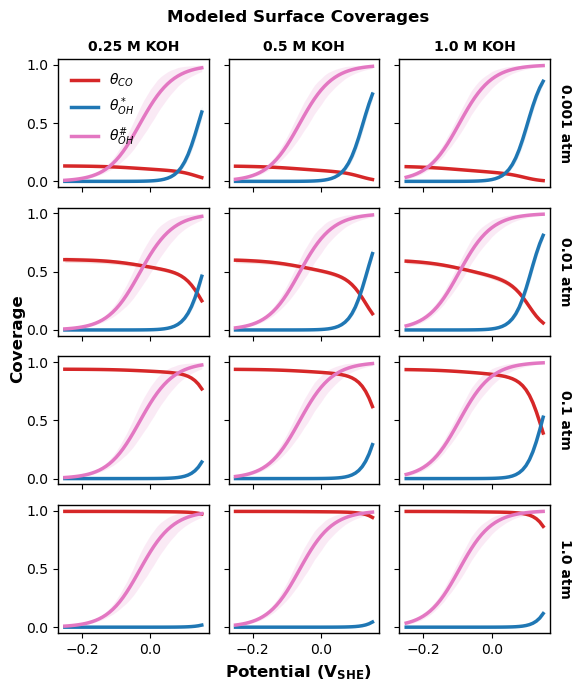

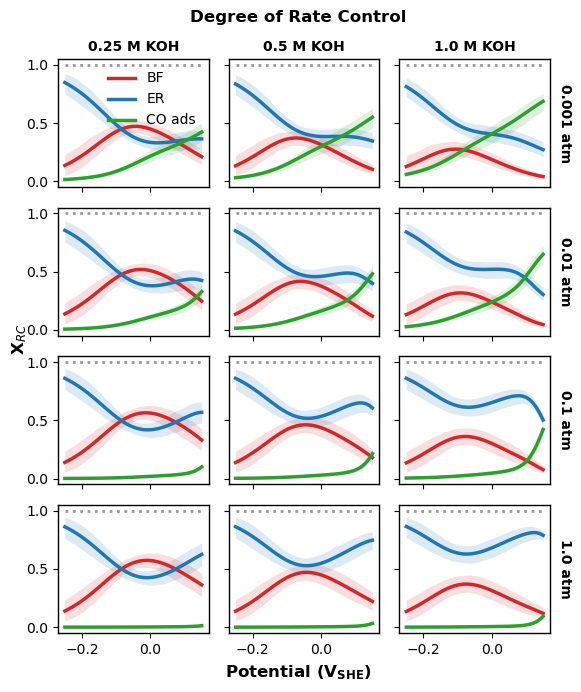

In [4]:
with pm.Model() as CO_BF_ER:
    '''
    1. CO + * <-> CO* (SSA)
    2a. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (SSA)
    2b. CO* + OH- -> COOH* + * + (e-) (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) 
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) 
    beta_2_BF = pm.Uniform('beta_2_BF', lower=0.0, upper=1.0)
    beta_2_ER = pm.Uniform('beta_2_ER', lower=0.0, upper=1.0)
    q = pm.Uniform('q', lower=0.0, upper=1.0)
    Gact1_0 = pm.TruncatedNormal('Gact1_0', mu=0.7, sigma=0.2, lower=0.0)
    Gact2_BF_0 = pm.TruncatedNormal('Gact2_BF_0', mu=0.7, sigma=0.2, lower=0.0)
    Gact2_ER_0 = pm.TruncatedNormal('Gact2_ER_0', mu=0.7, sigma=0.2, lower=0.0)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact1 = Gact1_0
    Gact2_BF = Gact2_BF_0 - beta_2_BF * (1.0 - q) * E_in
    Gact2_ER = Gact2_ER_0 - beta_2_ER * E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k1 = np.log(kb_J*T/h) - Gact1/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)

    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_OH_Ag)
    log_theta_Ag = -pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    log_A_Pd = pt.logsumexp(pt.stack([zeros, term_OH_Pd]), axis=0) 
    log_k1_PCO = log_k1 + np.log(P_CO_in)                    
    log_k_minus_1 = log_k1 - log_K1                                
    log_k_BF_app = log_k2_BF + log_theta_OH_Ag + np.log(Ag_comp)     
    log_k_ER_app = log_k2_ER + np.log(C_KOH_in)
    log_denom_Pd = pt.logsumexp(pt.stack([log_k1_PCO, log_A_Pd + log_k_minus_1, log_A_Pd + log_k_BF_app, log_A_Pd + log_k_ER_app]), axis=0)

    log_theta_CO = log_k1_PCO - log_denom_Pd
    log_theta_Pd = pt.logsumexp(pt.stack([log_k_minus_1 + zeros, log_k_BF_app, log_k_ER_app]), axis=0) - log_denom_Pd 
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_k_total_app = pt.logaddexp(log_k_BF_app, log_k_ER_app)
    log_rate = log_k_total_app + log_theta_CO
    rate = observables(log_rate) 

trace_CO_BF_ER, loo_CO_BF_ER = fit_and_evaluate(CO_BF_ER)

ppc_CO_BF_ER = plot_posteriors(trace_CO_BF_ER, CO_BF_ER)
plot_model_fits(trace_CO_BF_ER, ppc_CO_BF_ER, loo_CO_BF_ER); plot_coverages(trace_CO_BF_ER)
plot_drc(CO_BF_ER, trace_CO_BF_ER, perturb_vars=['Gact2_BF_0', 'Gact2_ER_0', 'Gact1_0'], perturb_labels=['BF', 'ER', 'CO ads'])

# Final

Progress,Draws,Divergences,Step Size,Gradients/Draw
,4000,0,0.14,63
,4000,0,0.14,63
,4000,0,0.15,159
,4000,0,0.13,31


Computed from 8000 posterior samples and 1476 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   678.84    55.80
p_loo        7.80        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1476  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



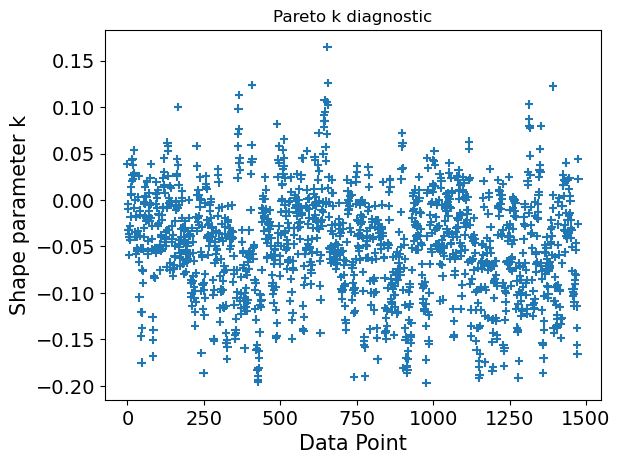

Sampling: [Gact1_0, Gact2_BF_0, Gact2_ER_0, Gact2_LH_0, beta_2_BF, beta_2_ER, deltaG1_0, deltaG4_0, deltaG5_0, q, sigma_rel]


             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0   0.103  0.003   0.097    0.108      0.000    0.000    3285.0    3609.0    1.0
deltaG5_0  -0.052  0.009  -0.069   -0.035      0.000    0.000    1096.0    1832.0    1.0
deltaG1_0  -0.127  0.001  -0.130   -0.125      0.000    0.000    3527.0    4030.0    1.0
beta_2_BF   0.011  0.011   0.000    0.030      0.000    0.001    4315.0    4181.0    1.0
beta_2_ER   0.217  0.005   0.207    0.226      0.000    0.000    4704.0    5067.0    1.0
q           0.544  0.053   0.447    0.641      0.002    0.001    1218.0    1954.0    1.0
Gact1_0     0.582  0.003   0.576    0.588      0.000    0.000    2926.0    3130.0    1.0
Gact2_BF_0  0.724  0.004   0.716    0.732      0.000    0.000    1057.0    1769.0    1.0
Gact2_ER_0  0.725  0.002   0.722    0.728      0.000    0.000    1259.0    1832.0    1.0
Gact2_LH_0  0.848  0.073   0.735    0.983      0.001    0.001    2759.0    2238.0    1.0
sigma_rel   0.272  0.

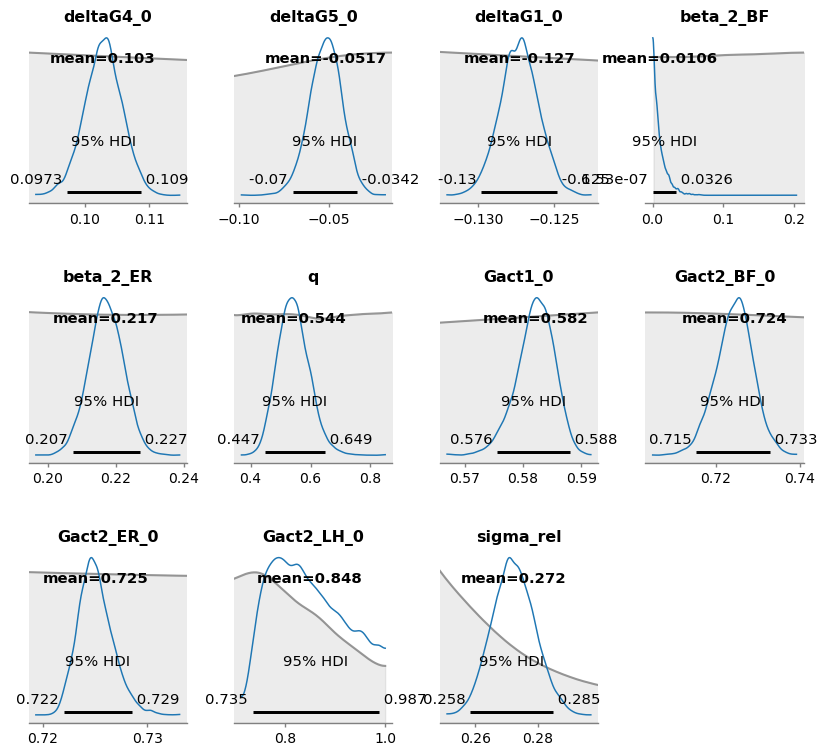

c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\plots\backends\matplotlib\pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


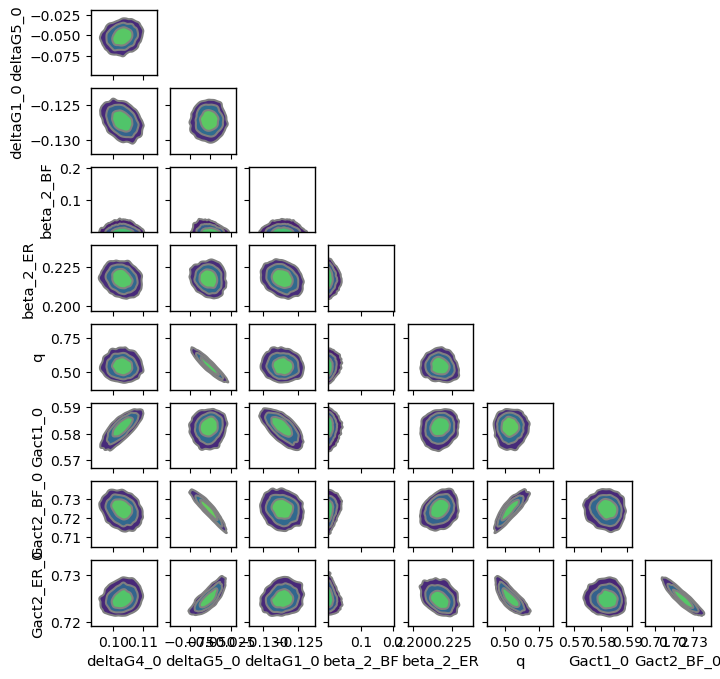

Sampling: [rate]


rate: 0.796


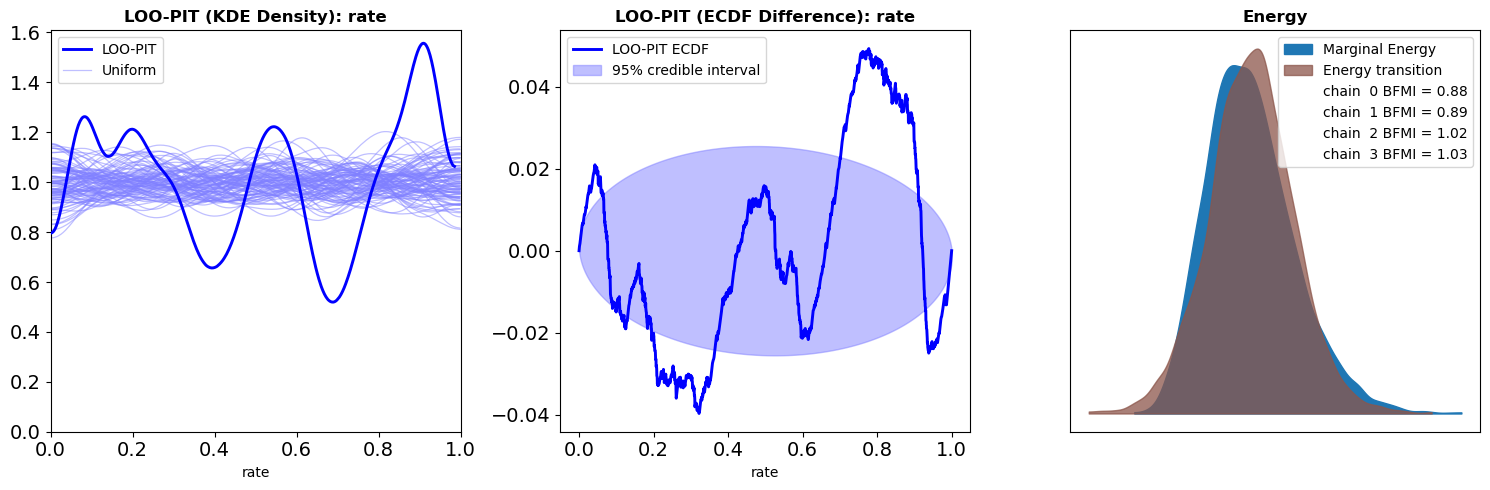

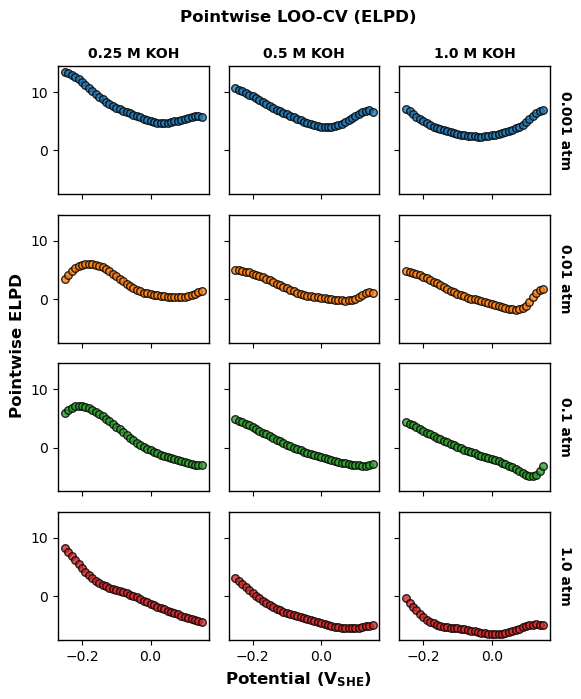

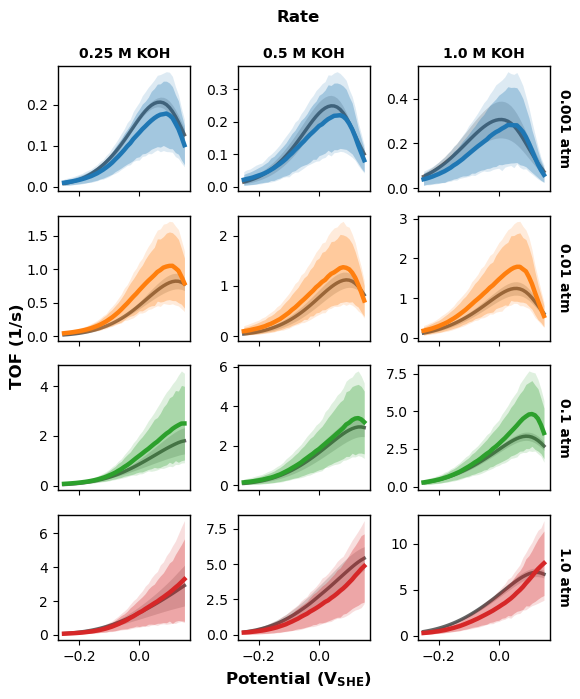

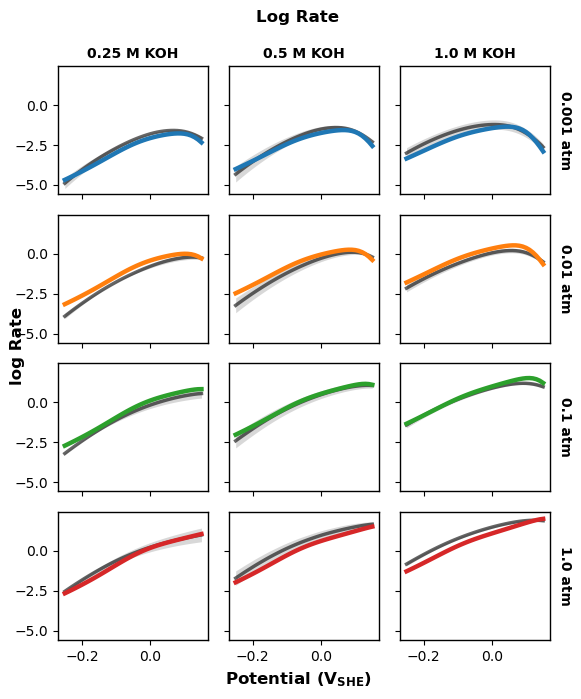

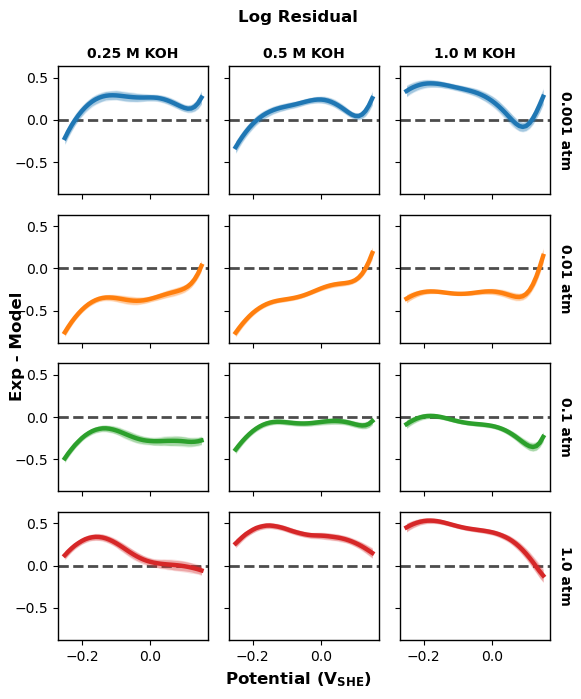

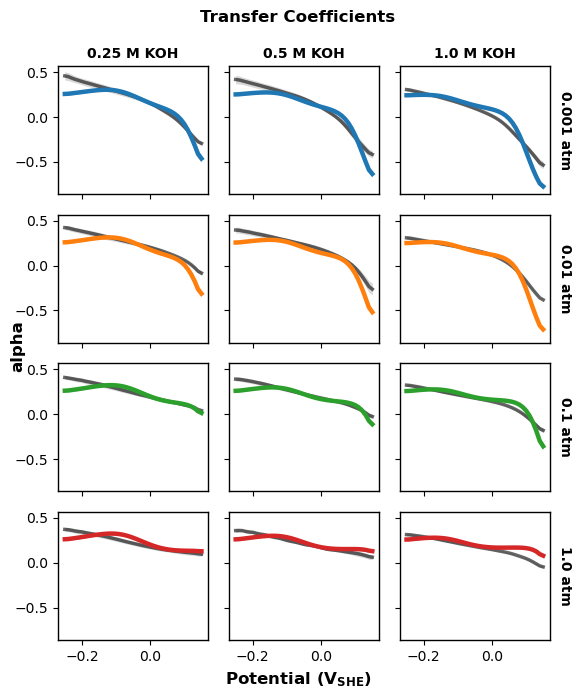

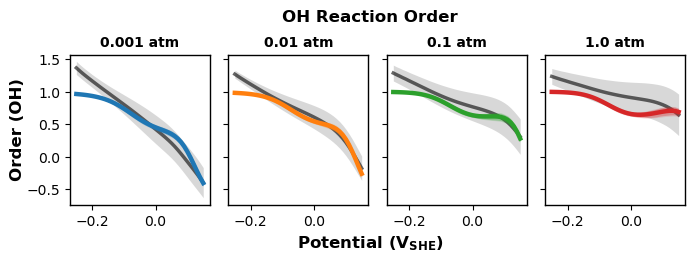

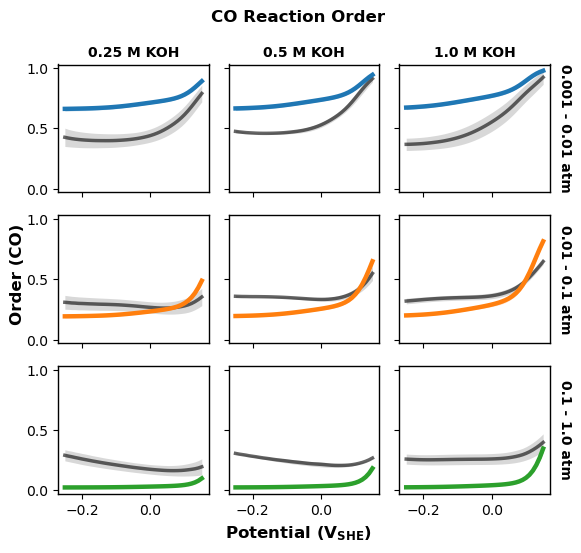

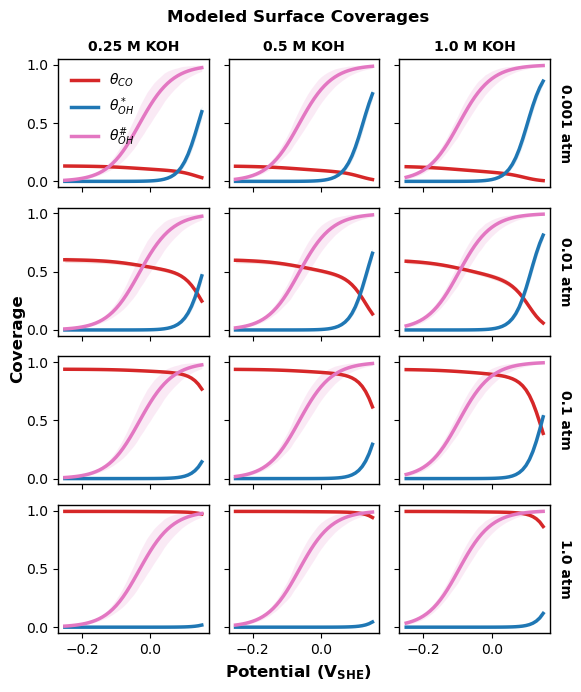

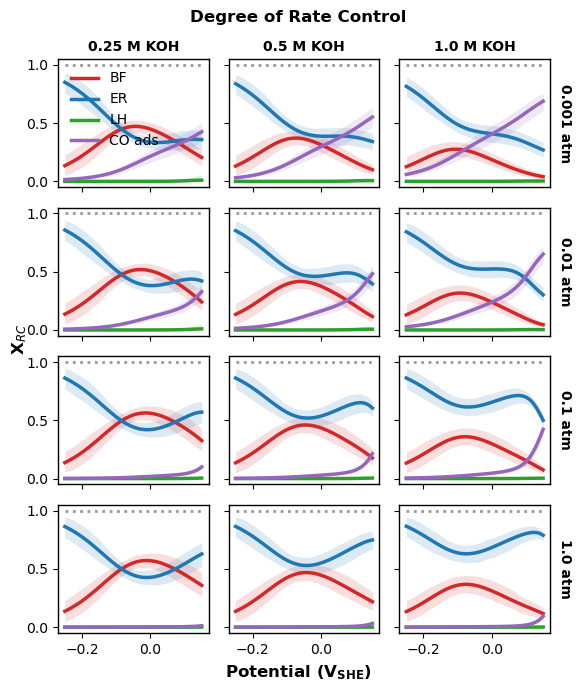

In [5]:
with pm.Model() as CO_BF_ER_LH:
    '''
    1. CO + * <-> CO* (SSA)
    2a. CO* + OH(q-1)# -> COOH* + # + (1-q)(e-) (SSA) (BF)
    2b. CO* + OH- -> COOH* + * + (e-) (SSA) (ER)
    2c. CO* + OH* -> COOH* + * (SSA) (LH)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    5. OH- + # <-> OH(q-1)# + (q)(e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.TruncatedNormal('deltaG1_0', mu=-0.4, sigma=0.2, upper=0.0, lower=-0.4)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2)
    deltaG5_0 = pm.Normal('deltaG5_0', mu=0.0, sigma=0.2) 
    beta_2_BF = pm.Uniform('beta_2_BF', lower=0.0, upper=1.0)
    beta_2_ER = pm.Uniform('beta_2_ER', lower=0.0, upper=1.0)
    q = pm.Uniform('q', lower=0.0, upper=1.0)
    Gact1_0 = pm.TruncatedNormal('Gact1_0', mu=0.7, sigma=0.2, lower=0.0, upper=1.0)
    Gact2_BF_0 = pm.TruncatedNormal('Gact2_BF_0', mu=0.7, sigma=0.2, lower=0.5, upper=1.0)
    Gact2_ER_0 = pm.TruncatedNormal('Gact2_ER_0', mu=0.7, sigma=0.2, lower=0.5, upper=1.0)
    Gact2_LH_0 = pm.TruncatedNormal('Gact2_LH_0', mu=0.7, sigma=0.2, lower=0.5, upper=1.0)

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG5 = deltaG5_0 - q * E_in
    Gact1 = Gact1_0
    Gact2_BF = Gact2_BF_0 - beta_2_BF * (1.0 - q) * E_in
    Gact2_ER = Gact2_ER_0 - beta_2_ER * E_in
    Gact2_LH = Gact2_LH_0
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K5 = -deltaG5/(kb_eV*T)
    log_k1 = np.log(kb_J*T/h) - Gact1/(kb_eV*T)
    log_k2_BF = np.log(kb_J*T/h) - Gact2_BF/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)

    term_OH_Ag = log_K5 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_OH_Ag)
    log_theta_Ag = -pt.logsumexp(pt.stack([zeros, term_OH_Ag]), axis=0)
    log_theta_OH_Ag = term_OH_Ag + log_theta_Ag
    term_OH_Pd = log_K4 + np.log(C_KOH_in)
    log_A_Pd = pt.logsumexp(pt.stack([zeros, term_OH_Pd]), axis=0) 
    log_k1_PCO = log_k1 + np.log(P_CO_in)                    
    log_k_minus_1 = log_k1 - log_K1                                
    log_k_BF_app = log_k2_BF + log_theta_OH_Ag + np.log(Ag_comp)     
    log_k_ER_app = log_k2_ER + np.log(C_KOH_in)
    log_k_LH_app = log_k2_LH + term_OH_Pd + np.log(1.0 - Ag_comp) 

    # Quadratic solution for empty Pd site fraction
    k1_PCO = pt.exp(log_k1_PCO)
    A_Pd = pt.exp(log_A_Pd)
    log_k_cons = pt.logaddexp(pt.logaddexp(log_k_BF_app, log_k_ER_app), log_k_minus_1)
    k_cons = pt.exp(log_k_cons)
    k_LH_app = pt.exp(log_k_LH_app)
    a = k_LH_app * A_Pd
    b = k1_PCO + k_cons * A_Pd - k_LH_app
    c = -k_cons
    theta_empty_Pd_val = (2 * c) / (-b - pt.sqrt(b**2 - 4 * a * c)) # Analytical solution to quadratic SSA
    log_theta_Pd = pt.log(theta_empty_Pd_val)
    log_theta_CO = pt.log(1.0 - A_Pd * theta_empty_Pd_val)
    log_theta_OH_Pd = term_OH_Pd + log_theta_Pd

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH_star = pm.Deterministic('theta_OH_star', pt.exp(log_theta_OH_Pd))
    theta_OH_pound = pm.Deterministic('theta_OH_pound', pt.exp(log_theta_OH_Ag))
    theta_empty_Pd = pm.Deterministic('theta_empty_Pd', pt.exp(log_theta_Pd))
    theta_empty_Ag = pm.Deterministic('theta_empty_Ag', pt.exp(log_theta_Ag))

    # Rate expression
    log_k_total_app = pt.logaddexp(pt.logaddexp(log_k_BF_app, log_k_ER_app), log_k_LH_app + log_theta_Pd) 
    log_rate = log_k_total_app + log_theta_CO
    rate = observables(log_rate)

trace_CO_BF_ER_LH, loo_CO_BF_ER_LH = fit_and_evaluate(CO_BF_ER_LH, target_accept=0.95, draws=2000)

ppc_CO_BF_ER_LH = plot_posteriors(trace_CO_BF_ER_LH, CO_BF_ER_LH)
plot_model_fits(trace_CO_BF_ER_LH, ppc_CO_BF_ER_LH, loo_CO_BF_ER_LH); plot_coverages(trace_CO_BF_ER_LH)
plot_drc(CO_BF_ER_LH, trace_CO_BF_ER_LH, perturb_vars=['Gact2_BF_0', 'Gact2_ER_0', 'Gact2_LH_0', 'Gact1_0'], perturb_labels=['BF', 'ER', 'LH', 'CO ads'])

# Comparison

             rank    elpd_loo      p_loo  elpd_diff        weight         se        dse  warning scale
CO_BF_ER        0  678.939358   7.794084   0.000000  1.000000e+00  55.815104   0.000000    False   log
CO_BF_ER_LH     1  678.837498   7.795210   0.101860  0.000000e+00  55.803854   0.121788    False   log
BF_ER           2  634.024304  19.267273  44.915054  2.878696e-12  55.905316   7.497768    False   log
BF              3  622.001855   5.959329  56.937503  0.000000e+00  55.453448  10.172046    False   log


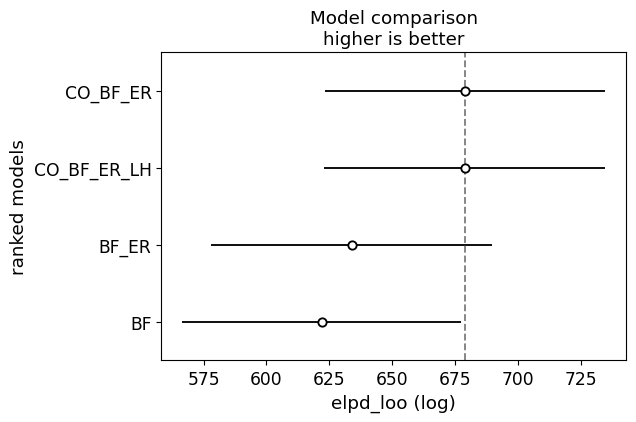

In [6]:
comparison_dict = {
    "BF": loo_BF, 
    "BF_ER": loo_BF_ER,
    "CO_BF_ER": loo_CO_BF_ER,
    "CO_BF_ER_LH": loo_CO_BF_ER_LH
}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()